In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import re

In [112]:
pwd

'/carnegie/nobackup/scratch/tbellagio/pang/test_freqk/pilot_site4'

In [117]:
# ---- paths ----
PILOT = Path("/home/tbellagio/scratch/pang/test_freqk/pilot_site4")
RESULTS = PILOT / "results"

K = 31

# ---- load ID -> original mapping ----
# expected: 2 columns, no header

def read_ref_index(ref_index_path: Path) -> pd.DataFrame:
    chroms = []
    poss = []
    with open(ref_index_path, "r") as f:
        for line in f:
            # we only need fields 2 and 3, so split just enough
            # format is: <something>,<chrom>,<pos>,<HUGE_FIELD...>
            parts = line.rstrip("\n").split(",", 3)
            if len(parts) < 3:
                continue
            chroms.append(parts[1])
            poss.append(int(parts[2]) + 2)  # your +2 correction

    idx = pd.DataFrame({"chrom": pd.Series(chroms, dtype="string"),
                        "pos": pd.Series(poss, dtype="int64")})
    idx["chrom"] = idx["chrom"].astype(str)
    return idx


def read_allele_freqs(af_path: Path) -> pd.DataFrame:
    rows = []
    max_cols = 0
    with open(af_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("|")
            rows.append(parts)
            if len(parts) > max_cols:
                max_cols = len(parts)

    # pad ragged rows
    rows = [r + [np.nan] * (max_cols - len(r)) for r in rows]

    cols = ["ref"] + [f"alt{i}" for i in range(1, max_cols)]
    af = pd.DataFrame(rows, columns=cols)
    return af

In [118]:
# ---- iterate over all samples ----
af_files = sorted(RESULTS.glob(f"**/*.allele_frequencies.k{K}.dedup.tsv"))
print(f"Found {len(af_files)} allele_frequencies files")

Found 46 allele_frequencies files


In [126]:
for af_path in af_files:
    ## only process seedmix 
    if '/S' in str(af_path):
        print(str(af_path))
        # infer site4 id from filename: site4_000.allele_frequencies.k31.dedup.tsv
        site4_id = af_path.name.split(".")[0]  # "site4_000"
    
        # matching ref_index in same folder (freqk outputs)
        # example: site4_000.k31.freqk.ref_index
        ref_index_path = af_path.parent / f"{site4_id}.k{K}.freqk.ref_index"
        if not ref_index_path.exists():
            print(f"SKIP (missing ref_index): {ref_index_path}")
            continue
    
        idx = read_ref_index(ref_index_path)
        af = read_allele_freqs(af_path)
    
        if len(idx) != len(af):
            print(f"WARNING length mismatch for {site4_id}: idx={len(idx)} af={len(af)} (will inner-truncate)")
            n = min(len(idx), len(af))
            idx = idx.iloc[:n].reset_index(drop=True)
            af = af.iloc[:n].reset_index(drop=True)
    
        df = pd.concat([idx.reset_index(drop=True), af.reset_index(drop=True)], axis=1)
    
        out_path = af_path.parent / f"{site4_id}.allele_frequencies.k{K}.dedup.processed.tsv"
        df.to_csv(out_path, sep="\t", index=False)
        print(f"WROTE {out_path}")

/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S1/k31/S1.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S1/k31/S1.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S2/k31/S2.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S2/k31/S2.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S3/k31/S3.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S3/k31/S3.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S4/k31/S4.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S4/k31/S4.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S5/k31/S5.allele_frequencies.k31.dedup.tsv
WROTE /ho

In [ ]:
af_files = sorted(RESULTS.glob(f"**/*.allele_frequencies.k{K}.dedup.processed.tsv"))
print(f"Found {len(af_files)} allele_frequencies files")bbb

In [129]:
BASE = Path("/home/tbellagio/scratch/pang/test_freqk/pilot_site4")
RESULTS = BASE / "results"
K = 31

# grab ONLY seedmix S1..S8 processed files (ignore site4_*)
af_files = []
for s in range(1, 9):
    af_files += list((RESULTS / f"S{s}" / f"k{K}").glob(f"S{s}.allele_frequencies.k{K}.dedup.processed.tsv"))

af_files = sorted(af_files)

In [130]:
af_files

[PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S1/k31/S1.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S2/k31/S2.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S3/k31/S3.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S4/k31/S4.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S5/k31/S5.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S6/k31/S6.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S7/k31/S7.allele_frequencies.k31.dedup.processed.tsv'),
 PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/S8/k31/S8.allele_frequencies.k31

'S8'

In [139]:
dfs = []
for p in af_files:
    df = pd.read_csv(p, sep="\t")
    # enforce types / consistent keys
    df["chrom"] = df["chrom"].astype(str)
    df["pos"] = df["pos"].astype(int)
    df['sample'] = str(p).split('/')[-3]
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

In [140]:
all_df

,chrom,pos,ref,alt1,alt2,alt3,alt4,sample
0,Chr1,59,0.989583,0.010417,NaN,NaN,NaN,S1
1,Chr1,67,0.217371,0.162242,0.511319,0.0,0.109068,S1
2,Chr1,1925,0.576341,0.423659,NaN,NaN,NaN,S1
3,Chr1,2290,0.844639,0.155361,NaN,NaN,NaN,S1
4,Chr1,2309,0.806691,0.193309,NaN,NaN,NaN,S1
...,...,...,...,...,...,...,...,...
9524067,Chr5,26974469,0.871429,0.128571,NaN,NaN,NaN,S8
9524068,Chr5,26974552,0.600583,0.399417,NaN,NaN,NaN,S8
9524069,Chr5,26974567,0.950464,0.049536,NaN,NaN,NaN,S8
9524070,Chr5,26974598,0.902439,0.097561,NaN,NaN,NaN,S8


In [141]:
# average across samples (skip NaNs)
mean_df = (
    all_df
    .groupby(["chrom", "pos"], as_index=False)
    .mean(numeric_only=True)
)


In [143]:
mean_df.to_csv('seed_mix_mean_af.csv',index=None)

In [27]:

import pandas as pd
from pathlib import Path

# ---- paths ----
PILOT = Path("/home/tbellagio/scratch/pang/test_freqk/pilot_site4")
RESULTS = PILOT / "results"

K = 31

# ---- load ID -> original mapping ----
# expected: 2 columns, no header
m = pd.read_csv(MAP_PATH, sep="\t", header=None, names=["site4_id", "original"])
id2orig = dict(zip(m["site4_id"], m["original"]))

def read_ref_index(ref_index_path: Path) -> pd.DataFrame:
    chroms = []
    poss = []
    with open(ref_index_path, "r") as f:
        for line in f:
            # we only need fields 2 and 3, so split just enough
            # format is: <something>,<chrom>,<pos>,<HUGE_FIELD...>
            parts = line.rstrip("\n").split(",", 3)
            if len(parts) < 3:
                continue
            chroms.append(parts[1])
            poss.append(int(parts[2]) + 2)  # your +2 correction

    idx = pd.DataFrame({"chrom": pd.Series(chroms, dtype="string"),
                        "pos": pd.Series(poss, dtype="int64")})
    idx["chrom"] = idx["chrom"].astype(str)
    return idx


def read_allele_freqs(af_path: Path) -> pd.DataFrame:
    rows = []
    max_cols = 0
    with open(af_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("|")
            rows.append(parts)
            if len(parts) > max_cols:
                max_cols = len(parts)

    # pad ragged rows
    rows = [r + [np.nan] * (max_cols - len(r)) for r in rows]

    cols = ["ref"] + [f"alt{i}" for i in range(1, max_cols)]
    af = pd.DataFrame(rows, columns=cols)
    return af

# ---- iterate over all samples ----
af_files = sorted(RESULTS.glob(f"**/*.allele_frequencies.k{K}.dedup.tsv"))
print(f"Found {len(af_files)} allele_frequencies files")

for af_path in af_files:
    print(af_path)

    # only process site samples 
    if 'site' in str(af_path):
    # infer site4 id from filename: site4_000.allele_frequencies.k31.dedup.tsv
        site4_id = af_path.name.split(".")[0]  # "site4_000"
    
        # matching ref_index in same folder (freqk outputs)
        # example: site4_000.k31.freqk.ref_index
        ref_index_path = af_path.parent / f"{site4_id}.k{K}.freqk.ref_index"
        if not ref_index_path.exists():
            print(f"SKIP (missing ref_index): {ref_index_path}")
            continue
    
        idx = read_ref_index(ref_index_path)
        af = read_allele_freqs(af_path)
    
        if len(idx) != len(af):
            print(f"WARNING length mismatch for {site4_id}: idx={len(idx)} af={len(af)} (will inner-truncate)")
            n = min(len(idx), len(af))
            idx = idx.iloc[:n].reset_index(drop=True)
            af = af.iloc[:n].reset_index(drop=True)
    
        df = pd.concat([idx.reset_index(drop=True), af.reset_index(drop=True)], axis=1)
    
        out_path = af_path.parent / f"{site4_id}.allele_frequencies.k{K}.dedup.processed.tsv"
        df.to_csv(out_path, sep="\t", index=False)
        print(f"WROTE {out_path}")


Found 38 allele_frequencies files
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_000/k31/site4_000.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_000/k31/site4_000.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_001/k31/site4_001.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_001/k31/site4_001.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_002/k31/site4_002.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_002/k31/site4_002.allele_frequencies.k31.dedup.processed.tsv
/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_003/k31/site4_003.allele_frequencies.k31.dedup.tsv
WROTE /home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_003/k31/site4_003.allele_fr

In [28]:
af_files = sorted(RESULTS.glob(f"**/*.allele_frequencies.k{K}.dedup.processed.tsv"))
print(f"Found {len(af_files)} allele_frequencies files")

Found 38 allele_frequencies files


In [30]:
MAP_PATH = PILOT / "site4_id_to_original.tsv"   # two cols: site4_000 <tab> MLFH...

In [97]:
og_samples = pd.read_csv( "/home/tbellagio/scratch/pang/test_freqk/pilot_site4/site4_id_to_original.tsv", sep = '\t', header=None)

In [99]:
og_samples

s = og_samples[1].astype(str)

og_samples["code"] = s.str[:4]
og_samples["site"] = s.str[4:6].astype(int)
og_samples["plot"] = s.str[6:8].astype(int)

og_samples["year"] = s.str[8:12].astype(int)
og_samples["month"] = s.str[12:14].astype(int)
og_samples["day"] = s.str[14:16].astype(int)

og_samples["date"] = pd.to_datetime(
    og_samples[["year", "month", "day"]],
    errors="coerce"
)

In [101]:
og_samples['year'].value_counts()

year
2018    40
2019    36
Name: count, dtype: int64

In [104]:
grenenet_samples = pd.read_csv('/home/tbellagio/scratch/grene/data/samples_data.csv')

In [106]:
grenenet_samples[grenenet_samples['site'] == 4]

,sampleid,code,site,plot,date,year,month,day,flowerscollected,isreplicate,isfailedlabwork,isdispersion,sampleid_alternative,generation,generation_merge57,mapped_reads,coverage,usesample,weighted_mean_coverage
186,MLFH040120180306,FH,4,1,20180306,2018,3,6,100,False,False,False,NaN,1,1,15312985.0,15.312985,True,16.631347
187,MLFH040120180321,FH,4,1,20180321,2018,3,21,100,False,False,False,NaN,1,1,17949709.0,17.949709,True,16.631347
188,MLFH040120190208,FH,4,1,20190208,2019,2,8,25,False,False,False,NaN,2,2,16600813.0,16.600813,True,9.314159
189,MLFH040120190221,FH,4,1,20190221,2019,2,21,55,False,False,False,NaN,2,2,6002044.0,6.002044,True,9.314159
190,MLFH040120200206,FH,4,1,20200206,2020,2,6,40,False,False,False,NaN,3,3,5276738.0,5.276738,True,5.276738
191,MLFH040220180306,FH,4,2,20180306,2018,3,6,100,False,False,False,NaN,1,1,19525576.0,19.525576,True,21.163674
192,MLFH040220180321,FH,4,2,20180321,2018,3,21,100,False,False,False,NaN,1,1,22801773.0,22.801773,True,21.163674
193,MLFH040220190208,FH,4,2,20190208,2019,2,8,25,False,False,False,NaN,2,2,3694208.0,3.694208,True,2.803439
194,MLFH040220190221,FH,4,2,20190221,2019,2,21,35,False,False,False,NaN,2,2,2167175.0,2.167175,True,2.803439
195,MLFH040220200212,FH,4,2,20200212,2020,2,12,50,False,False,False,NaN,3,3,7741156.0,7.741156,True,7.741156


In [31]:
MAP_PATH

PosixPath('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/site4_id_to_original.tsv')

In [32]:
from pathlib import Path
import pandas as pd
import re

# af_files = sorted(RESULTS.glob(f"**/*.allele_frequencies.k{K}.dedup.processed.tsv"))
MAP_PATH = Path("/home/tbellagio/scratch/pang/test_freqk/pilot_site4/site4_id_to_original.tsv")

# mapping file: 2 columns, no header
m = pd.read_csv(MAP_PATH, sep="\t", header=None, names=["site4_id", "original"])
m["site4_id"] = m["site4_id"].astype(str)

def extract_site4_id(p: Path) -> str:
    s = str(p)
    # robust: find site4_### anywhere in the path
    m = re.search(r"(site4_\d{3})", s)
    return m.group(1) if m else None

have = pd.DataFrame({"path": [str(p) for p in af_files]})
have["site4_id"] = [extract_site4_id(Path(p)) for p in have["path"]]

# attach original sample name
have = have.merge(m, on="site4_id", how="left")

# convenient extra fields
have["mlfh_folder"] = have["original"].str.split("_").str[0]  # e.g., MLFH040320180306
have["orig_prefix"] = have["original"].str.replace(r"_L\d+_([12])\.fq\.gz$", r"_\1.fq.gz", regex=True)

# sort nicely
have = have.sort_values(["site4_id"]).reset_index(drop=True)

print(f"Found {len(have)} allele_frequencies files")
print(f"Mapped: {(have['original'].notna()).sum()} / {len(have)}")

display(have[["site4_id", "mlfh_folder", "original", "path"]].head(20))


Found 38 allele_frequencies files
Mapped: 38 / 38


,site4_id,mlfh_folder,original,path
0,site4_000,MLFH040320180306,MLFH040320180306_CKDL210001610-1a-AK10689-AK90...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
1,site4_001,MLFH040320180321,MLFH040320180321_CKDL210001610-1a-AK34068-AK90...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
2,site4_002,MLFH040320190208,MLFH040320190208_CKDL210001610-1a-AK34069-AK90...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
3,site4_003,MLFH040320190221,MLFH040320190221_CKDL210001610-1a-AK34070-AK90...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
4,site4_004,MLFH040420180306,MLFH040420180306_CKDL210001610-1a-AK31398-AK90...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
5,site4_005,MLFH040420180321,MLFH040420180321_CKDL210001610-1a-AK7838-AK901...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
6,site4_006,MLFH040520180306,MLFH040520180306_CKDL210006836-1a-AK34069-AK89...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
7,site4_007,MLFH040520180321,MLFH040520180321_CKDL210006836-1a-AK34070-AK89...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
8,site4_008,MLFH040520190208,MLFH040520190208_CKDL210006836-1a-AK11638-AK89...,/home/tbellagio/scratch/pang/test_freqk/pilot_...
9,site4_009,MLFH040520190221,MLFH040520190221_CKDL210006836-1a-AK33987-AK89...,/home/tbellagio/scratch/pang/test_freqk/pilot_...


In [34]:
import pandas as pd

s = have["mlfh_folder"].astype(str)

have["code"] = s.str[:4]
have["site"] = s.str[4:6].astype(int)
have["plot"] = s.str[6:8].astype(int)

have["year"] = s.str[8:12].astype(int)
have["month"] = s.str[12:14].astype(int)
have["day"] = s.str[14:16].astype(int)

have["date"] = pd.to_datetime(
    have[["year", "month", "day"]],
    errors="coerce"
)

In [37]:
have[['year', 'plot']].value_counts()

year  plot
2018  3       2
2019  3       2
      11      2
      10      2
      9       2
      8       2
      7       2
      6       2
      5       2
2018  12      2
      4       2
      11      2
      10      2
      9       2
      8       2
      7       2
      6       2
      5       2
2019  12      2
Name: count, dtype: int64

In [42]:
have[have['year'] == 2019]['path'][2]

'/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_002/k31/site4_002.allele_frequencies.k31.dedup.processed.tsv'

In [1]:
import allel 
vcf_og = allel.read_vcf('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/set_05_rep1.vcf.gz')

In [4]:
vcf_og['calldata/GT'].shape

(1870021, 4, 2)

In [7]:
snarl_qc = pd.read_csv('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/qc_snarls/qc_sizes_set_05_rep1.per_alt.tsv', sep = '\t')

In [17]:
# ---- aggregate to one row per CHROM/POS/ID ----
def collapse_class(x: pd.Series) -> str:
    u = pd.unique(x.dropna())
    if len(u) == 1:
        return str(u[0])
    return "MIXED"

gcols = ["chrom", "pos", "id"]

og_snarls = (
    snarl_qc.groupby(gcols, as_index=False)
      .agg(
          alt_index_num=("alt_index", "max"),            # assumes alt_index is 1..K; max==K
          size_signed_avg=("size_signed", "mean"),
          size_bp_avg=("size_bp", "mean"),
          is_conflict=("is_conflict", "max"),            # if any allele flagged conflict => 1
          ref_len=("ref_len", "first"),                  # should be constant per site
          alt_len_avg=("alt_len", "mean"),
      )
)

In [18]:
og_snarls

,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg
0,Chr1,1,>1>159,3,3047.666667,3047.666667,0,58,3105.666667
1,Chr1,59,>159>161,1,82.000000,82.000000,0,1,83.000000
2,Chr1,62,>161>164,1,0.000000,0.000000,0,1,1.000000
3,Chr1,63,>164>168,2,-0.500000,0.500000,0,3,2.500000
4,Chr1,67,>168>302,4,-639.250000,766.250000,0,1857,1217.750000
...,...,...,...,...,...,...,...,...,...
1870016,Chr5,26974567,>6642189>6642192,1,0.000000,0.000000,0,1,1.000000
1870017,Chr5,26974598,>6642192>6642194,1,14.000000,14.000000,0,1,15.000000
1870018,Chr5,26974603,>6642194>6642197,1,0.000000,0.000000,0,1,1.000000
1870019,Chr5,26974605,>6642197>6642200,1,0.000000,0.000000,0,1,1.000000


In [19]:
freq = pd.read_csv('/home/tbellagio/scratch/pang/test_freqk/pilot_site4/results/site4_002/k31/site4_002.allele_frequencies.k31.dedup.processed.tsv', sep = '\t')

In [23]:
og_snarls.shape

(1870021, 9)

In [22]:
freq.shape

(1190509, 7)

In [26]:
og = og_snarls.copy()
fr = freq.copy()

In [27]:
fr_keys = fr[["chrom", "pos"]].drop_duplicates()

In [29]:
m = og.merge(fr_keys, on=["chrom", "pos"], how="left", indicator=True)
missed_snarls = m.loc[m["_merge"] == "left_only"].drop(columns=["_merge"])

In [31]:
missed_snarls.shape

(679512, 9)

In [33]:
missed_snarls

,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg
0,Chr1,1,>1>159,3,3047.666667,3047.666667,0,58,3105.666667
2,Chr1,62,>161>164,1,0.000000,0.000000,0,1,1.000000
3,Chr1,63,>164>168,2,-0.500000,0.500000,0,3,2.500000
27,Chr1,6768,>372>375,1,0.000000,0.000000,0,1,1.000000
57,Chr1,10595,>465>468,1,0.000000,0.000000,0,1,1.000000
...,...,...,...,...,...,...,...,...,...
1870006,Chr5,26974232,>6642161>6642164,1,0.000000,0.000000,0,1,1.000000
1870009,Chr5,26974278,>6642169>6642172,1,0.000000,0.000000,0,1,1.000000
1870010,Chr5,26974279,>6642172>6642174,1,-5.000000,5.000000,0,6,1.000000
1870018,Chr5,26974603,>6642194>6642197,1,0.000000,0.000000,0,1,1.000000


In [24]:
snarls_freq = og_snarls.merge(freq, on = ['chrom', 'pos'])

In [34]:
import numpy as np
import pandas as pd

def summarize_snarls(
    df: pd.DataFrame,
    *,
    class_col: str = "class",
    size_signed_col: str = "size_signed_avg",
    prefix: str = "",
    include_total: bool = True,
) -> pd.Series:
    """
    Summarize snarl/allele records by class and signed-size bins.

    Expects:
      - df[class_col] like: SNP, MNP, INS, DEL, SYMBOLIC, OTHER, ...
      - df[size_signed_col] signed sizes (INS positive, DEL negative, 0 for SNP/MNP)

    Returns a 1-row pd.Series suitable for concat into a summary table.
    """
    out = {}

    if include_total:
        out[f"{prefix}n_records"] = int(len(df))

    # ----- class counts -----
    cls = df[class_col] if class_col in df.columns else pd.Series([np.nan] * len(df))
    class_counts = cls.value_counts(dropna=False)
    for k, v in class_counts.items():
        key = "NA" if pd.isna(k) else str(k)
        out[f"{prefix}class_count_{key}"] = int(v)

    # ----- signed-size bins -----
    s = pd.to_numeric(df[size_signed_col], errors="coerce") if size_signed_col in df.columns else pd.Series([np.nan]*len(df))

    # if you want to ignore NaN sizes in binning, keep as is; comparisons with NaN become False
    out[f"{prefix}n_size_nan"] = int(s.isna().sum())

    out[f"{prefix}n_size_0"]          = int((s == 0).sum())
    out[f"{prefix}n_small_ins_1_40"]  = int(((s >= 1) & (s <= 40)).sum())
    out[f"{prefix}n_small_del_1_m40"] = int(((s <= -1) & (s >= -40)).sum())
    out[f"{prefix}n_mid_ins_41_10k"]  = int(((s >= 41) & (s <= 10_000)).sum())
    out[f"{prefix}n_mid_del_41_m10k"] = int(((s <= -41) & (s >= -10_000)).sum())
    out[f"{prefix}n_large_ins_10k"]   = int((s > 10_000).sum())
    out[f"{prefix}n_large_del_10k"]   = int((s < -10_000).sum())

    return pd.Series(out)


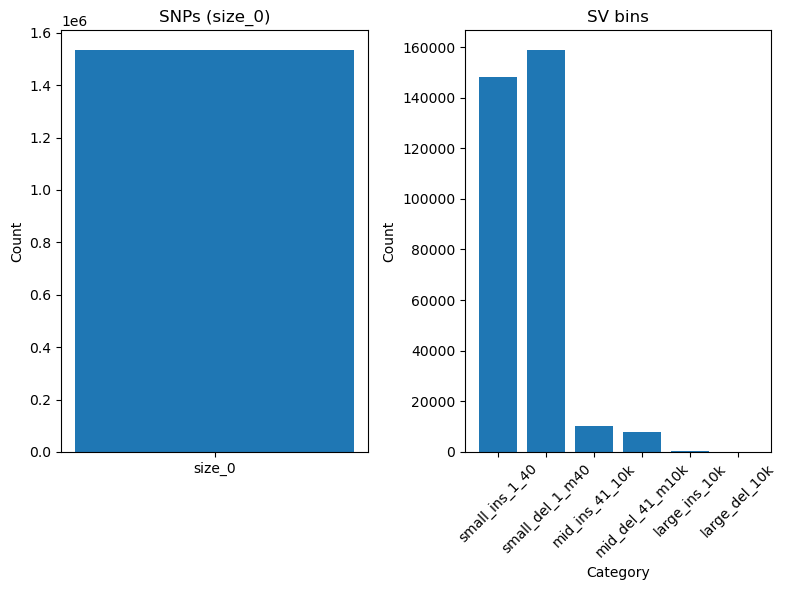

In [54]:
summ_og   = summarize_snarls(og_snarls, prefix="og_")
# Create a DataFrame for plotting
df_plot = pd.DataFrame(list(summ_og.items()), columns=["category", "count"])

df_plot["category"] = df_plot["category"].str.replace("og_n_", "", regex=False)

df_plot_snps = df_plot.iloc[3:4,:]
df_plot_sv = df_plot.iloc[4:,:]
# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=False)

# SNPs
axes[0].bar(df_plot_snps["category"], df_plot_snps["count"])
axes[0].set_title("SNPs (size_0)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# SVs
axes[1].bar(df_plot_sv["category"], df_plot_sv["count"])
axes[1].set_title("SV bins")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

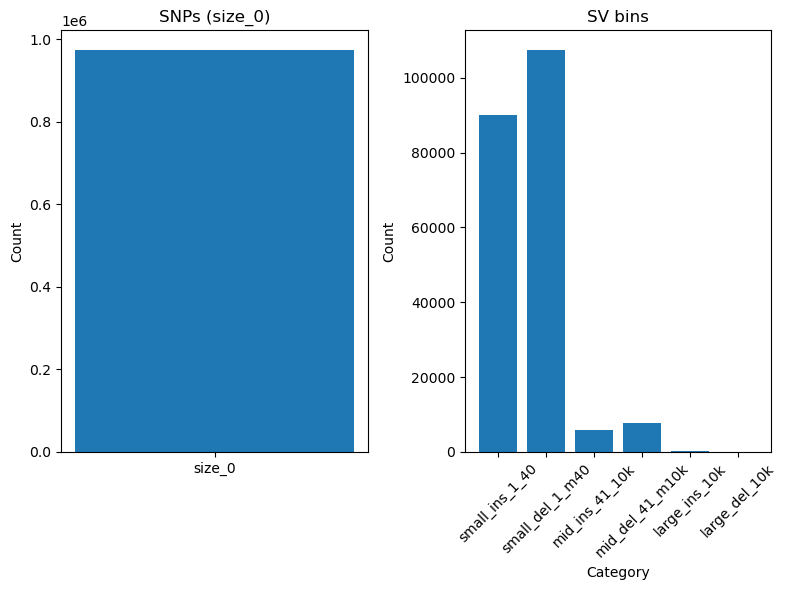

In [55]:
summ_freq   = summarize_snarls(snarls_freq, prefix="og_")
# Create a DataFrame for plotting
df_plot = pd.DataFrame(list(summ_freq.items()), columns=["category", "count"])

df_plot["category"] = df_plot["category"].str.replace("og_n_", "", regex=False)

df_plot_snps = df_plot.iloc[3:4,:]
df_plot_sv = df_plot.iloc[4:,:]
# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=False)

# SNPs
axes[0].bar(df_plot_snps["category"], df_plot_snps["count"])
axes[0].set_title("SNPs (size_0)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# SVs
axes[1].bar(df_plot_sv["category"], df_plot_sv["count"])
axes[1].set_title("SV bins")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

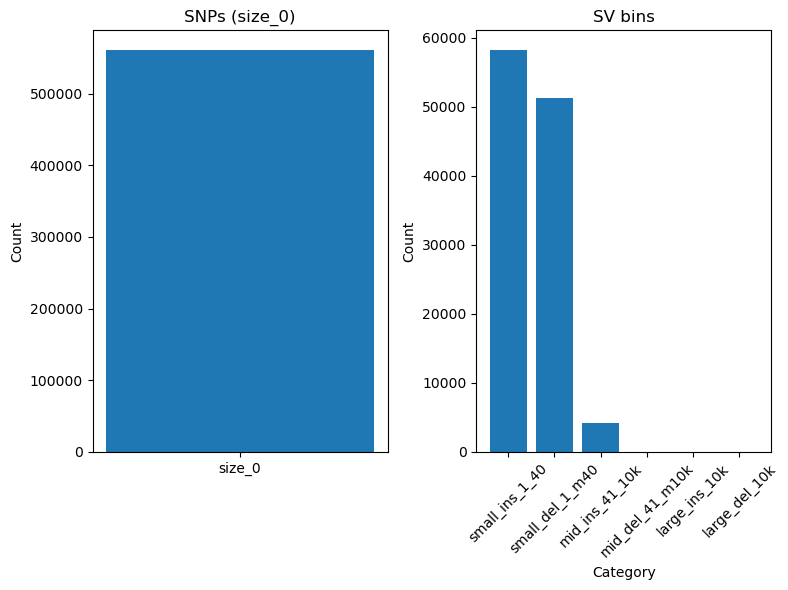

In [56]:
summ_missed   = summarize_snarls(missed_snarls, prefix="og_")
# Create a DataFrame for plotting
df_plot = pd.DataFrame(list(summ_missed.items()), columns=["category", "count"])

df_plot["category"] = df_plot["category"].str.replace("og_n_", "", regex=False)

df_plot_snps = df_plot.iloc[3:4,:]
df_plot_sv = df_plot.iloc[4:,:]
# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=False)

# SNPs
axes[0].bar(df_plot_snps["category"], df_plot_snps["count"])
axes[0].set_title("SNPs (size_0)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# SVs
axes[1].bar(df_plot_sv["category"], df_plot_sv["count"])
axes[1].set_title("SV bins")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [59]:
summ_og

og_n_records            1870021
og_class_count_NA       1870021
og_n_size_nan                 0
og_n_size_0             1532749
og_n_small_ins_1_40      148141
og_n_small_del_1_m40     158686
og_n_mid_ins_41_10k       10050
og_n_mid_del_41_m10k       7829
og_n_large_ins_10k          174
og_n_large_del_10k           96
dtype: int64

In [57]:
summ_freq

og_n_records            1190509
og_class_count_NA       1190509
og_n_size_nan                 0
og_n_size_0              972589
og_n_small_ins_1_40       89964
og_n_small_del_1_m40     107350
og_n_mid_ins_41_10k        5863
og_n_mid_del_41_m10k       7829
og_n_large_ins_10k          139
og_n_large_del_10k           96
dtype: int64

In [58]:
summ_missed

og_n_records            679512
og_class_count_NA       679512
og_n_size_nan                0
og_n_size_0             560160
og_n_small_ins_1_40      58177
og_n_small_del_1_m40     51336
og_n_mid_ins_41_10k       4187
og_n_mid_del_41_m10k         0
og_n_large_ins_10k          35
og_n_large_del_10k           0
dtype: int64

In [60]:
import pandas as pd
import numpy as np

def enrichment_table(summ_og, summ_freq, summ_missed, prefix="og_"):
    # pick the bins you care about (your existing keys)
    cats = [
        "n_size_0",
        "n_small_ins_1_40",
        "n_small_del_1_m40",
        "n_mid_ins_41_10k",
        "n_mid_del_41_m10k",
        "n_large_ins_10k",
        "n_large_del_10k",
    ]

    def get(s, key):  # safe getter
        return int(s.get(prefix + key, 0))

    # counts per category
    og = {c: get(summ_og, c) for c in cats}
    fr = {c: get(summ_freq, c) for c in cats}
    ms = {c: get(summ_missed, c) for c in cats}

    df = pd.DataFrame({"og": og, "freq": fr, "missed": ms}).T  # rows=dataset
    df = df.T  # rows=category

    # totals for these bins (ignore size_nan etc)
    df["og_total"] = df["og"].sum()
    df["freq_total"] = df["freq"].sum()
    df["missed_total"] = df["missed"].sum()

    # proportions within each dataset
    df["og_pct"] = df["og"] / df["og_total"]
    df["freq_pct"] = df["freq"] / df["freq_total"]
    df["missed_pct"] = df["missed"] / df["missed_total"]

    # enrichment of missed vs OG (ratio of proportions)
    df["missed_vs_og_enrichment"] = df["missed_pct"] / df["og_pct"]

    # also compute a coarse SNP vs SV collapse
    og_snp = og["n_size_0"]
    ms_snp = ms["n_size_0"]
    fr_snp = fr["n_size_0"]

    og_sv = sum(og[c] for c in cats if c != "n_size_0")
    ms_sv = sum(ms[c] for c in cats if c != "n_size_0")
    fr_sv = sum(fr[c] for c in cats if c != "n_size_0")

    coarse = pd.DataFrame({
        "og": {"SNP(size0)": og_snp, "SV(nonzero)": og_sv},
        "freq": {"SNP(size0)": fr_snp, "SV(nonzero)": fr_sv},
        "missed": {"SNP(size0)": ms_snp, "SV(nonzero)": ms_sv},
    })

    coarse["og_pct"] = coarse["og"] / coarse["og"].sum()
    coarse["freq_pct"] = coarse["freq"] / coarse["freq"].sum()
    coarse["missed_pct"] = coarse["missed"] / coarse["missed"].sum()
    coarse["missed_vs_og_enrichment"] = coarse["missed_pct"] / coarse["og_pct"]

    return df, coarse


In [61]:
detail, coarse = enrichment_table(summ_og, summ_freq, summ_missed, prefix="og_")

# nicer display
coarse_display = coarse.copy()
for col in ["og_pct","freq_pct","missed_pct"]:
    coarse_display[col] = (100*coarse_display[col]).round(2)

coarse_display["missed_vs_og_enrichment"] = coarse_display["missed_vs_og_enrichment"].round(3)

coarse_display


,og,freq,missed,og_pct,freq_pct,missed_pct,missed_vs_og_enrichment
SNP(size0),1532749,972589,560160,82.51,82.16,83.12,1.007
SV(nonzero),324976,211241,113735,17.49,17.84,16.88,0.965


In [63]:
import pandas as pd
from scipy.stats import fisher_exact

def snp_vs_sv_41bp(summ_og, summ_freq, summ_missed, prefix="og_"):
    # bins we’ll aggregate
    small_bins = ["n_size_0", "n_small_ins_1_40", "n_small_del_1_m40"]
    sv_bins    = ["n_mid_ins_41_10k", "n_mid_del_41_m10k", "n_large_ins_10k", "n_large_del_10k"]

    def get(s, key):
        return int(s.get(prefix + key, 0))

    def agg(s):
        small = sum(get(s, k) for k in small_bins)
        sv    = sum(get(s, k) for k in sv_bins)
        return small, sv

    og_small, og_sv = agg(summ_og)
    fr_small, fr_sv = agg(summ_freq)
    ms_small, ms_sv = agg(summ_missed)

    # composition table
    df = pd.DataFrame(
        {
            "og":     {"small_<=40_or_0": og_small, "SV_>=41": og_sv},
            "freq":   {"small_<=40_or_0": fr_small, "SV_>=41": fr_sv},
            "missed": {"small_<=40_or_0": ms_small, "SV_>=41": ms_sv},
        }
    )

    # percent within each dataset
    pct = df.div(df.sum(axis=0), axis=1) * 100

    # enrichment: missed composition / og composition
    enrich = (pct["missed"] / pct["og"]).rename("missed_vs_og_enrichment")

    # Fisher exact on 2x2: missed vs not_missed by class (SV vs small)
    table = [
        [ms_sv, ms_small],
        [og_sv - ms_sv, og_small - ms_small],
    ]
    oddsratio, p = fisher_exact(table)

    stats = {
        "og_small": og_small, "og_sv": og_sv,
        "missed_small": ms_small, "missed_sv": ms_sv,
        "freq_small": fr_small, "freq_sv": fr_sv,
        "SV_missed_vs_og_enrichment": float(enrich["SV_>=41"]),
        "small_missed_vs_og_enrichment": float(enrich["small_<=40_or_0"]),
        "fisher_oddsratio_SV_enriched_if_gt1": float(oddsratio),
        "fisher_pvalue": float(p),
        "fisher_table_[ [missed_SV, missed_small], [notmissed_SV, notmissed_small] ]": table,
    }

    return df, pct, enrich, stats

df_counts, df_pct, enrich, stats = snp_vs_sv_41bp(summ_og, summ_freq, summ_missed, prefix="og_")

print("Counts:\n", df_counts, "\n")
print("Percents (within each dataset):\n", df_pct.round(3), "\n")
print("Enrichment (missed% / og%):\n", enrich.round(3), "\n")


Counts:
                       og     freq  missed
small_<=40_or_0  1839576  1169903  669673
SV_>=41            18149    13927    4222 

Percents (within each dataset):
                      og    freq  missed
small_<=40_or_0  99.023  98.824  99.373
SV_>=41           0.977   1.176   0.627 

Enrichment (missed% / og%):
 small_<=40_or_0    1.004
SV_>=41            0.641
Name: missed_vs_og_enrichment, dtype: float64 



In [21]:
samples = pd.read_csv('site4_id_to_original.tsv', sep = '\t', header=None)

In [23]:
samples

,0,1
0,site4_000,MLFH040320180306_CKDL210001610-1a-AK10689-AK90...
1,site4_001,MLFH040320180321_CKDL210001610-1a-AK34068-AK90...
2,site4_002,MLFH040320190208_CKDL210001610-1a-AK34069-AK90...
3,site4_003,MLFH040320190221_CKDL210001610-1a-AK34070-AK90...
4,site4_004,MLFH040420180306_CKDL210001610-1a-AK31398-AK90...
...,...,...
71,site4_071,MLFH041120190221_CKDL210008891-1a-AK7838-AK245...
72,site4_072,MLFH041220180306_CKDL210008891-1a-AK10689-AK24...
73,site4_073,MLFH041220180321_CKDL210008891-1a-AK34068-AK24...
74,site4_074,MLFH041220190208_CKDL210008891-1a-AK34069-AK24...


In [19]:
samples[1].str.split('_').str[0]

0     MLFH040320180306
1     MLFH040320180321
2     MLFH040320190208
3     MLFH040320190221
4     MLFH040420180306
            ...       
71    MLFH041120190221
72    MLFH041220180306
73    MLFH041220180321
74    MLFH041220190208
75    MLFH041220190221
Name: 1, Length: 76, dtype: object

In [14]:
#pd.read_csv('site4_reads.manifest.tsv', sep = '\t', header=None)

In [180]:
#cam5 
start = 11531967 - 5000
end = 11534358 + 5000

In [181]:
sm_af = pd.read_csv('seed_mix_mean_af.csv')

In [182]:
snarls_freq_sm = og_snarls.merge(sm_af, on = ['chrom', 'pos'])

In [183]:
snarls_freq_sm

,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg,ref,alt1,alt2,alt3,alt4
0,Chr1,59,>159>161,1,82.00,82.00,0,1,83.00,0.968248,0.031752,NaN,NaN,NaN
1,Chr1,67,>168>302,4,-639.25,766.25,0,1857,1217.75,0.237930,0.146725,0.445999,0.027335,0.142011
2,Chr1,1925,>302>305,1,1417.00,1417.00,0,1,1418.00,0.555083,0.444917,NaN,NaN,NaN
3,Chr1,2290,>305>308,1,0.00,0.00,0,1,1.00,0.931040,0.068960,NaN,NaN,NaN
4,Chr1,2309,>308>311,1,0.00,0.00,0,2,2.00,0.763874,0.236126,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190504,Chr5,26974469,>6642183>6642186,1,0.00,0.00,0,1,1.00,0.962712,0.037287,NaN,NaN,NaN
1190505,Chr5,26974552,>6642186>6642189,1,0.00,0.00,0,1,1.00,0.613600,0.386400,NaN,NaN,NaN
1190506,Chr5,26974567,>6642189>6642192,1,0.00,0.00,0,1,1.00,0.956986,0.043014,NaN,NaN,NaN
1190507,Chr5,26974598,>6642192>6642194,1,14.00,14.00,0,1,15.00,0.934386,0.065614,NaN,NaN,NaN


In [184]:
cam5_sm = snarls_freq_sm[snarls_freq_sm['chrom'] == 'Chr2']

cam5_sm = cam5_sm[(cam5_sm['pos'] >= start) & (cam5_sm['pos'] <= end)]

In [185]:
cam5 = snarls_freq[snarls_freq['chrom'] == 'Chr2']

cam5 = cam5[(cam5['pos'] >= start) & (cam5['pos'] <= end)]

In [186]:
cam5_sm.head(2)

,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg,ref,alt1,alt2,alt3,alt4
425082,Chr2,11527300,>2467073>2467076,1,0.0,0.0,0,1,1.0,0.809970,0.190030,NaN,NaN,NaN
425083,Chr2,11527386,>2467076>2467078,1,8.0,8.0,0,1,9.0,0.047411,0.952589,NaN,NaN,NaN


In [187]:
cam5.head(2)

,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg,ref,alt1,alt2,alt3,alt4
425082,Chr2,11527300,>2467073>2467076,1,0.0,0.0,0,1,1.0,0.888489,0.111511,NaN,NaN,NaN
425083,Chr2,11527386,>2467076>2467078,1,8.0,8.0,0,1,9.0,0.000000,1.000000,NaN,NaN,NaN


In [188]:
import pandas as pd
import re

def delta_alt_freq(site_df: pd.DataFrame,
                   seedmix_df: pd.DataFrame,
                   key=("chrom","pos"),
                   keep_meta=("id","alt_index_num","class","size_signed_avg","size_bp_avg","is_conflict","ref_len","alt_len_avg"),
                   how="inner") -> pd.DataFrame:
    site = site_df.copy()
    sm   = seedmix_df.copy()

    # keys types
    site["chrom"] = site["chrom"].astype(str); site["pos"] = site["pos"].astype(int)
    sm["chrom"]   = sm["chrom"].astype(str);   sm["pos"]   = sm["pos"].astype(int)

    # detect allele columns (alt1, alt2, ...)
    alt_cols_site = [c for c in site.columns if re.fullmatch(r"alt\d+", str(c))]
    alt_cols_sm   = [c for c in sm.columns   if re.fullmatch(r"alt\d+", str(c))]
    alt_cols = sorted(set(alt_cols_site).intersection(alt_cols_sm),
                      key=lambda x: int(x.replace("alt","")))

    # choose columns to carry through
    meta_cols = [c for c in keep_meta if c in site.columns]  # from site (same as sm usually)
    site_sub = site[list(key) + meta_cols + alt_cols].copy()
    sm_sub   = sm[list(key) + alt_cols].copy()

    # merge
    m = site_sub.merge(sm_sub, on=list(key), how=how, suffixes=("", "_sm"))

    # deltas
    for c in alt_cols:
        m[f"delta_{c}"] = m[c] - m[f"{c}_sm"]

    # optional: one combined delta if you just want “total alt”
    m["alt_sum"]    = m[alt_cols].sum(axis=1, skipna=True)
    m["alt_sum_sm"] = m[[f"{c}_sm" for c in alt_cols]].sum(axis=1, skipna=True)
    m["delta_alt_sum"] = m["alt_sum"] - m["alt_sum_sm"]

    return m

delta = delta_alt_freq(cam5, cam5_sm, how="inner")
delta.head()


,chrom,pos,id,alt_index_num,size_signed_avg,size_bp_avg,is_conflict,ref_len,alt_len_avg,alt1,...,alt2_sm,alt3_sm,alt4_sm,delta_alt1,delta_alt2,delta_alt3,delta_alt4,alt_sum,alt_sum_sm,delta_alt_sum
0,Chr2,11527300,>2467073>2467076,1,0.0,0.0,0,1,1.0,0.111511,...,NaN,NaN,NaN,-0.078519,NaN,NaN,NaN,0.111511,0.190030,-0.078519
1,Chr2,11527386,>2467076>2467078,1,8.0,8.0,0,1,9.0,1.000000,...,NaN,NaN,NaN,0.047411,NaN,NaN,NaN,1.000000,0.952589,0.047411
2,Chr2,11527461,>2467078>2467081,1,0.0,0.0,0,1,1.0,0.646632,...,NaN,NaN,NaN,0.317771,NaN,NaN,NaN,0.646632,0.328861,0.317771
3,Chr2,11527503,>2467081>2467083,1,-1.0,1.0,0,2,1.0,0.166987,...,NaN,NaN,NaN,-0.154579,NaN,NaN,NaN,0.166987,0.321566,-0.154579
4,Chr2,11527603,>2467083>2467086,1,0.0,0.0,0,1,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000


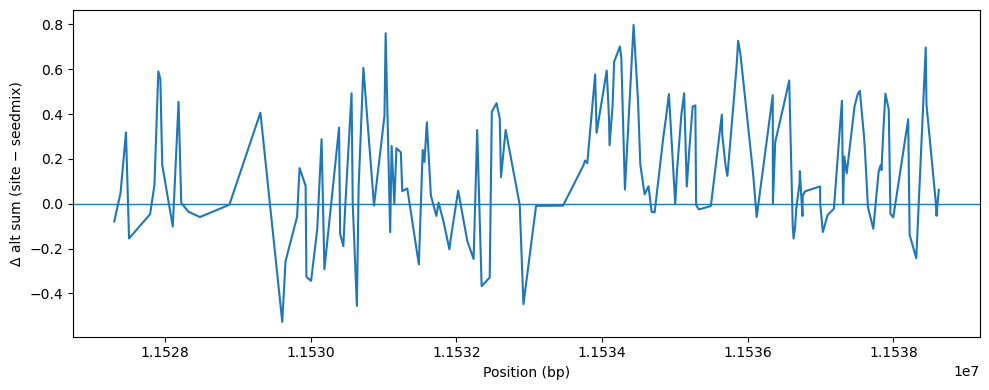

In [189]:
import matplotlib.pyplot as plt


d = delta[['chrom', 'pos', 'size_bp_avg', 'alt1', 'alt1_sm', 'delta_alt1', 'delta_alt_sum']]
d = d.dropna().copy()
d["pos"] = d["pos"].astype(int)
d = d.sort_values("pos")

plt.figure(figsize=(10,4))
plt.plot(d["pos"], d["delta_alt_sum"])
plt.axhline(0, linewidth=1)
plt.xlabel("Position (bp)")
plt.ylabel("Δ alt sum (site − seedmix)")
plt.tight_layout()
plt.show()


In [163]:
d.columns

Index(['chrom', 'pos', 'id', 'alt_index_num', 'size_signed_avg', 'size_bp_avg',
       'is_conflict', 'ref_len', 'alt_len_avg', 'alt1', 'alt2', 'alt3', 'alt4',
       'alt1_sm', 'alt2_sm', 'alt3_sm', 'alt4_sm', 'delta_alt1', 'delta_alt2',
       'delta_alt3', 'delta_alt4', 'alt_sum', 'alt_sum_sm', 'delta_alt_sum'],
      dtype='object')

In [169]:
d[['chrom', 'pos', 'size_bp_avg', 'alt1', 'alt1_sm', 'delta_alt1', 'delta_alt_sum']]

,chrom,pos,size_bp_avg,alt1,alt1_sm,delta_alt1,delta_alt_sum
0,Chr2,11532023,9.0,0.456869,0.398351,0.058518,0.058518
1,Chr2,11532148,0.0,0.199203,0.364881,-0.165678,-0.165678
2,Chr2,11532235,0.0,0.000000,0.246209,-0.246209,-0.246209
3,Chr2,11532284,0.0,0.660131,0.331732,0.328399,0.328399
4,Chr2,11532345,0.0,0.000000,0.367443,-0.367443,-0.367443
5,Chr2,11532456,0.0,0.000000,0.328603,-0.328603,-0.328603
6,Chr2,11532485,1.0,0.473684,0.063632,0.410052,0.410052
7,Chr2,11532550,0.0,0.647059,0.198344,0.448715,0.448715
8,Chr2,11532594,0.0,0.444444,0.064957,0.379487,0.379487
9,Chr2,11532611,0.0,1.000000,0.881363,0.118637,0.118637
